In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx

from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules

In [3]:
df = pd.read_csv(
    "Market_Basket_Optimisation.csv",
    header=None
)

df.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
0,shrimp,almonds,avocado,vegetables mix,green grapes,whole weat flour,yams,cottage cheese,energy drink,tomato juice,low fat yogurt,green tea,honey,salad,mineral water,salmon,antioxydant juice,frozen smoothie,spinach,olive oil
1,burgers,meatballs,eggs,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,chutney,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,turkey,avocado,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,mineral water,milk,energy bar,whole wheat rice,green tea,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
df.shape

(7501, 20)

In [5]:
transactions = []

for i in range(len(df)):
    transactions.append(
        [str(item) for item in df.iloc[i].dropna().tolist()]
    )

In [6]:
transactions[:5]

[['shrimp',
  'almonds',
  'avocado',
  'vegetables mix',
  'green grapes',
  'whole weat flour',
  'yams',
  'cottage cheese',
  'energy drink',
  'tomato juice',
  'low fat yogurt',
  'green tea',
  'honey',
  'salad',
  'mineral water',
  'salmon',
  'antioxydant juice',
  'frozen smoothie',
  'spinach',
  'olive oil'],
 ['burgers', 'meatballs', 'eggs'],
 ['chutney'],
 ['turkey', 'avocado'],
 ['mineral water', 'milk', 'energy bar', 'whole wheat rice', 'green tea']]

In [7]:
te = TransactionEncoder()

te_array = te.fit(transactions).transform(transactions)

basket = pd.DataFrame(
    te_array,
    columns=te.columns_
)

basket.head()

,asparagus,almonds,antioxydant juice,asparagus,avocado,babies food,bacon,barbecue sauce,black tea,blueberries,...,turkey,vegetables mix,water spray,white wine,whole weat flour,whole wheat pasta,whole wheat rice,yams,yogurt cake,zucchini
0,False,True,True,False,True,False,False,False,False,False,...,False,True,False,False,True,False,False,True,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,True,False,False,False,False,False,...,True,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False


In [8]:
top_items = basket.sum().sort_values(
    ascending=False
).head(10)

print(top_items)

mineral water        1788
eggs                 1348
spaghetti            1306
french fries         1282
chocolate            1229
green tea             991
milk                  972
ground beef           737
frozen vegetables     715
pancakes              713
dtype: int64


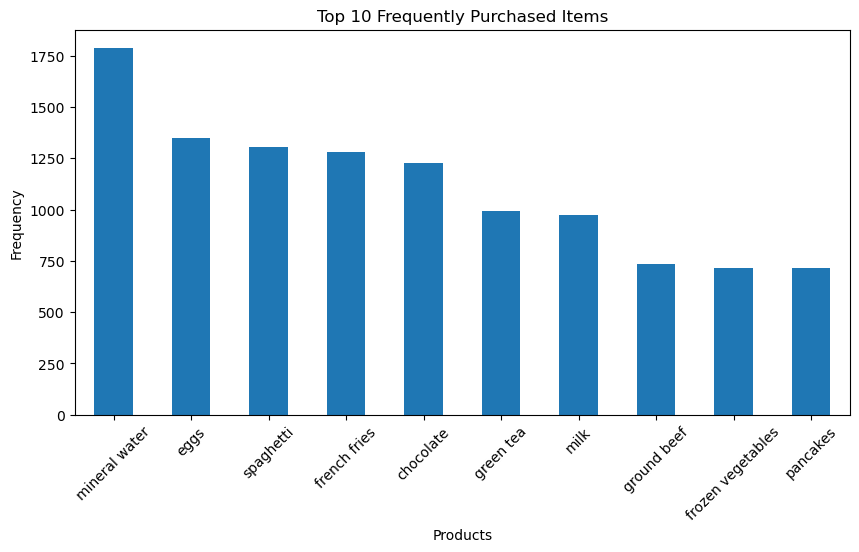

In [9]:
plt.figure(figsize=(10, 5))

top_items.plot(kind="bar")

plt.title("Top 10 Frequently Purchased Items")
plt.xlabel("Products")
plt.ylabel("Frequency")

plt.xticks(rotation=45)

plt.show()

In [10]:
frequent_items = apriori(
    basket,
    min_support=0.01,
    use_colnames=True
)

frequent_items = frequent_items.sort_values(
    by="support",
    ascending=False
)

frequent_items.head(10)

,support,itemsets
46,0.238368,(mineral water)
19,0.179709,(eggs)
63,0.174110,(spaghetti)
24,0.170911,(french fries)
13,0.163845,(chocolate)
32,0.132116,(green tea)
45,0.129583,(milk)
33,0.098254,(ground beef)
30,0.095321,(frozen vegetables)
53,0.095054,(pancakes)


In [11]:
rules = association_rules(
    frequent_items,
    metric="lift",
    min_threshold=1.2
)

rules = rules.sort_values(
    by="lift",
    ascending=False
)

rules.head(10)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
137,(herb & pepper),(ground beef),0.049460,0.098254,0.015998,0.323450,3.291994,1.0,0.011138,1.332860,0.732460,0.121457,0.249734,0.243136
136,(ground beef),(herb & pepper),0.098254,0.049460,0.015998,0.162822,3.291994,1.0,0.011138,1.135410,0.772094,0.121457,0.119261,0.243136
109,"(spaghetti, mineral water)",(ground beef),0.059725,0.098254,0.017064,0.285714,2.907928,1.0,0.011196,1.262445,0.697788,0.121097,0.207886,0.229696
112,(ground beef),"(spaghetti, mineral water)",0.098254,0.059725,0.017064,0.173677,2.907928,1.0,0.011196,1.137902,0.727602,0.121097,0.121190,0.229696
329,"(spaghetti, mineral water)",(olive oil),0.059725,0.065858,0.010265,0.171875,2.609786,1.0,0.006332,1.128021,0.656007,0.089017,0.113491,0.163873
332,(olive oil),"(spaghetti, mineral water)",0.065858,0.059725,0.010265,0.155870,2.609786,1.0,0.006332,1.113898,0.660314,0.089017,0.102252,0.163873
134,(frozen vegetables),(tomatoes),0.095321,0.068391,0.016131,0.169231,2.474464,1.0,0.009612,1.121381,0.658656,0.109304,0.108243,0.202549
135,(tomatoes),(frozen vegetables),0.068391,0.095321,0.016131,0.235867,2.474464,1.0,0.009612,1.183930,0.639616,0.109304,0.155355,0.202549
119,(shrimp),(frozen vegetables),0.071457,0.095321,0.016664,0.233209,2.446574,1.0,0.009853,1.179825,0.636767,0.111012,0.152417,0.204017
118,(frozen vegetables),(shrimp),0.095321,0.071457,0.016664,0.174825,2.446574,1.0,0.009853,1.125268,0.653563,0.111012,0.111323,0.204017


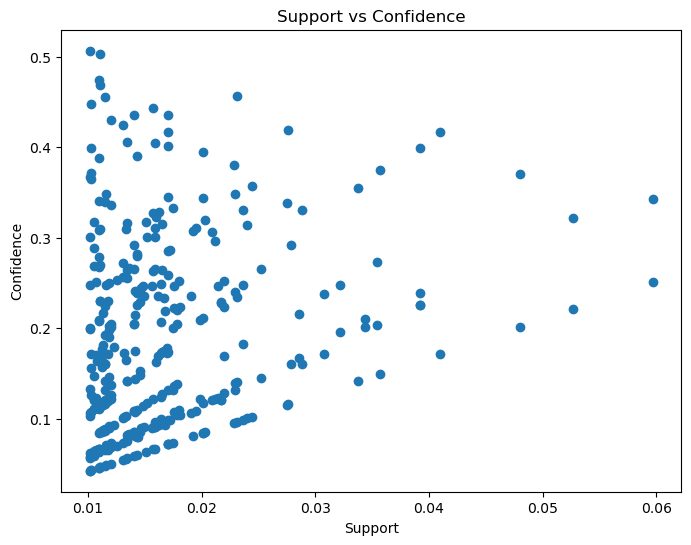

In [12]:
plt.figure(figsize=(8, 6))

plt.scatter(
    rules["support"],
    rules["confidence"]
)

plt.xlabel("Support")
plt.ylabel("Confidence")
plt.title("Support vs Confidence")

plt.show()

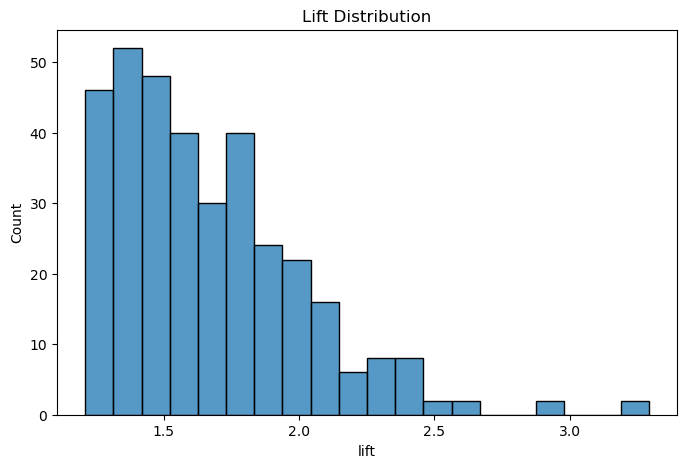

In [13]:
plt.figure(figsize=(8, 5))

sns.histplot(rules["lift"], bins=20)

plt.title("Lift Distribution")

plt.show()

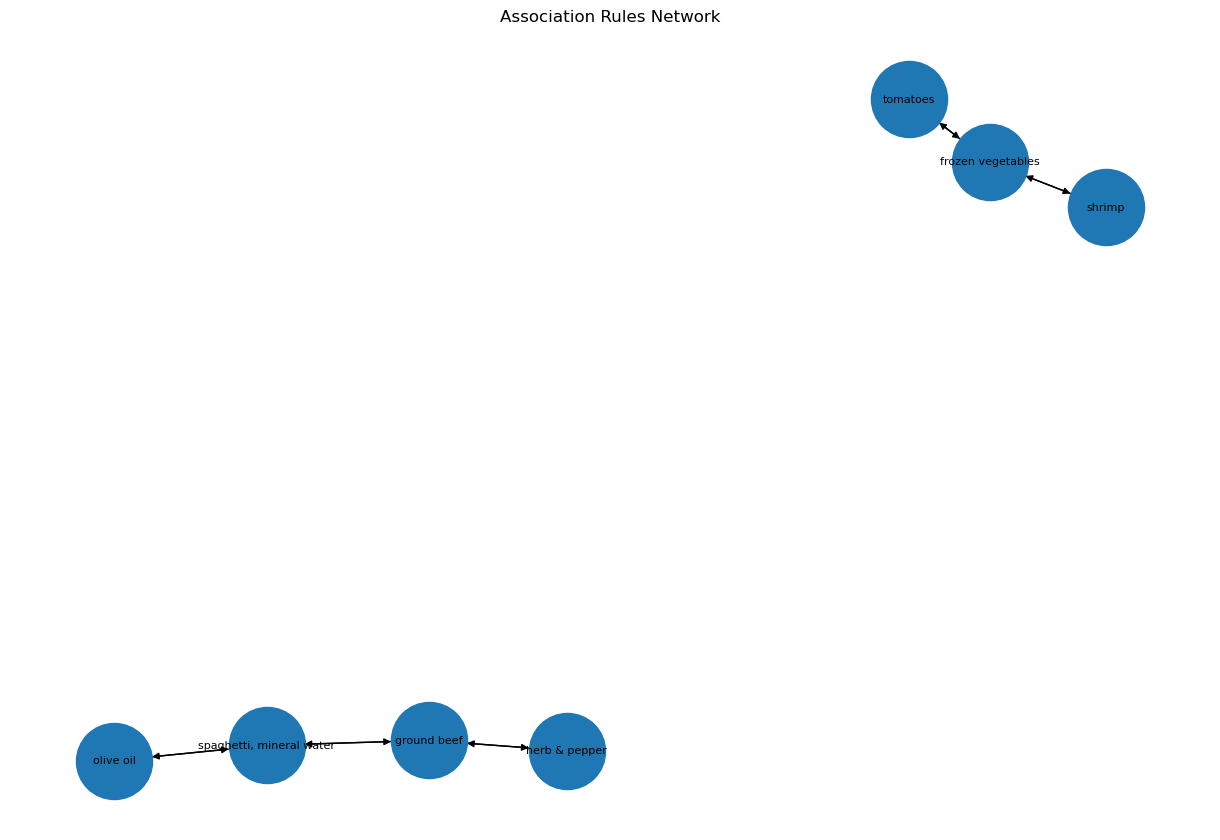

In [14]:
G = nx.DiGraph()

top_rules = rules.head(10)

for _, row in top_rules.iterrows():
    antecedent = ", ".join(list(row["antecedents"]))
    consequent = ", ".join(list(row["consequents"]))

    G.add_edge(
        antecedent,
        consequent,
        weight=row["lift"]
    )

plt.figure(figsize=(12, 8))

pos = nx.spring_layout(G, seed=42)

nx.draw(
    G,
    pos,
    with_labels=True,
    node_size=3000,
    font_size=8
)

plt.title("Association Rules Network")

plt.show()

In [15]:
print("1. Products with high lift values are strongly associated.")
print("2. Frequently purchased products can be bundled together.")
print("3. Association rules can improve cross-selling strategies.")
print("4. Product placement can be optimized using these insights.")

1. Products with high lift values are strongly associated.
2. Frequently purchased products can be bundled together.
3. Association rules can improve cross-selling strategies.
4. Product placement can be optimized using these insights.
